Puntajes de cada fold: [1.         1.         0.93333333 0.96666667 0.96666667]
Precisión media: 0.9733333333333334


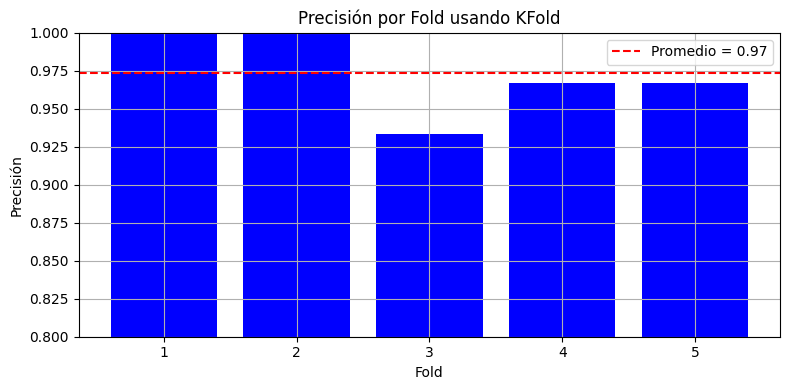

Precisión promedio: 0.97


In [ ]:
# Importar librerías necesarias
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import cross_val_score, KFold
from sklearn.linear_model import LogisticRegression
import numpy as np

# Cargar el dataset
iris = load_iris()
X, y = iris.data, iris.target

# Crear el modelo
modelo = LogisticRegression(max_iter=200)

# Configurar validación cruzada con 5 folds
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# Evaluar el modelo usando validación cruzada
resultados = cross_val_score(modelo, X, y, cv=kfold)
promedio = np.mean(resultados)

# Mostrar los resultados
print("Puntajes de cada fold:", resultados)
print("Precisión media:", np.mean(resultados))

# Gráfico de barras con color azul y línea roja de promedio
plt.figure(figsize=(8, 4))
plt.bar(range(1, 6), resultados, color='blue')
plt.axhline(y=promedio, color='red', linestyle='--', label=f'Promedio = {promedio:.2f}')
plt.ylim(0.8, 1.0)
plt.title('Precisión por Fold usando KFold')
plt.xlabel('Fold')
plt.ylabel('Precisión')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Imprimir precisión promedio
print(f"Precisión promedio: {promedio:.2f}")


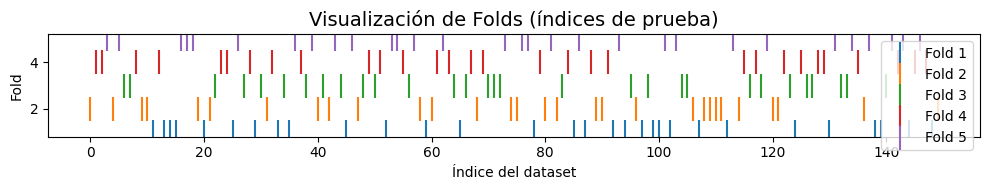

In [ ]:
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold

# Usamos StratifiedKFold para asegurar balance de clases en cada fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Visualizar cómo se dividen los datos
fig, ax = plt.subplots(1, 1, figsize=(10, 2))

for i, (train_index, test_index) in enumerate(cv.split(X, y)):
    # Visualizamos los índices de test en cada fold
    ax.scatter(test_index, [i + 1] * len(test_index), label=f'Fold {i+1}', marker='|', s=300)

ax.set_title('Visualización de Folds (índices de prueba)', fontsize=14)
ax.set_xlabel('Índice del dataset')
ax.set_ylabel('Fold')
ax.legend()
plt.tight_layout()
plt.show()


### ¿Qué muestra esta gráfica de validación cruzada?

Esta gráfica muestra **cómo se reparten los datos del dataset en los diferentes folds durante la validación cruzada**.

- **Eje X**: representa los índices de las muestras en el dataset.
- **Eje Y**: representa cada uno de los folds (por ejemplo, Fold 1, Fold 2, ..., Fold 5).

Cada rayita vertical (`|`) muestra **qué observaciones fueron utilizadas como conjunto de prueba en cada fold**. Por ejemplo:
- Las rayitas en la línea del Fold 1 son los índices usados como test en la primera iteración,
- Las del Fold 2 son los usados como test en la segunda, y así sucesivamente.

 Esto permite verificar visualmente que:
- Cada muestra se utiliza **una única vez como test** y **varias veces como entrenamiento**,
- No hay traslape entre los subconjuntos de prueba,
- El procedimiento rota sistemáticamente el conjunto de prueba, como se espera en una validación cruzada k-fold.

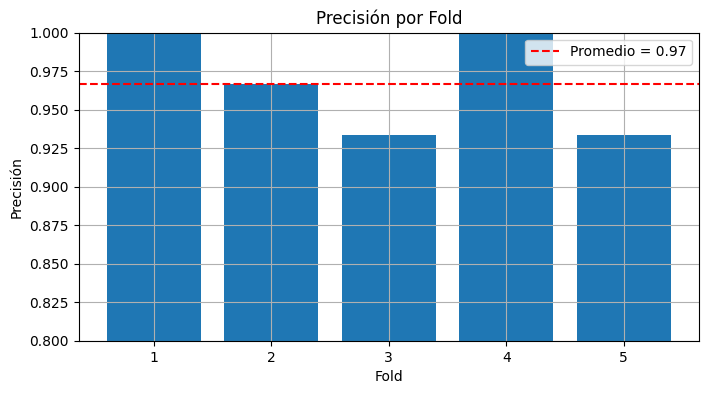

Precisión promedio: 0.97


In [ ]:
# Ejecutamos la validación cruzada y graficamos los resultados
resultados = cross_val_score(modelo, X, y, cv=cv)
promedio = np.mean(resultados)

# Gráfico de barras con los resultados
plt.figure(figsize=(8, 4))
plt.bar(range(1, 6), resultados)
plt.axhline(y=promedio, color='red', linestyle='--', label=f'Promedio = {promedio:.2f}')
plt.ylim(0.8, 1.0)
plt.title('Precisión por Fold')
plt.xlabel('Fold')
plt.ylabel('Precisión')
plt.grid(True)
plt.legend()
plt.show()

# Mostrar precisión promedio en consola
print(f"Precisión promedio: {promedio:.2f}")


### ¿Cuál es la diferencia entre `KFold` y `StratifiedKFold`?

- **`KFold`** divide los datos de forma aleatoria y uniforme, sin tener en cuenta las proporciones de las clases. Esto puede causar desequilibrios en los folds si el dataset es desbalanceado.
- **`StratifiedKFold`**, en cambio, mantiene la misma proporción de clases en cada fold. Por eso es especialmente útil en problemas de **clasificación**, ya que garantiza una evaluación más representativa y estable del modelo.
